In [98]:
import jax.numpy as jnp
from nucleotide_transformer_v3.pretrained import get_pretrained_ntv3_model
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict,GroupKFold,KFold
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score
from xgboost import XGBClassifier,XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import numpy as np
from sklearn.decomposition import PCA
import umap
from matplotlib import pyplot as plt
import seaborn as sns


In [100]:
# from huggingface_hub import notebook_login
# notebook_login()  # This will open a widget for login


In [101]:
from transformers import AutoTokenizer, AutoModelForMaskedLM,AutoModel

repo = "InstaDeepAI/NTv3_8M_pre"
tok = AutoTokenizer.from_pretrained(repo, trust_remote_code=True)
nt_model = AutoModelForMaskedLM.from_pretrained(repo, trust_remote_code=True)
#nt_model = AutoModel.from_pretrained(repo, trust_remote_code=True)

# Species tokens



# batch = tok(["ATCGNATCG", "ACGT"], add_special_tokens=False, padding=True, pad_to_multiple_of=128, return_tensors="pt")

# species = ['mouse']*len(batch['input_ids'])
# species_ids = nt_model.encode_species(species)

# out = nt_model(**batch, species_ids=species_ids)

# print(out.logits.shape)  # (B, L, V = 11)


In [102]:
# out = nt_model(**batch, output_hidden_states=True, output_attentions=True)

# # Access all hidden states (tuple of tensors, one per layer)
# hidden_states = out.hidden_states
# print(len(hidden_states))  # Number of layers
# print(hidden_states[0].shape)  # (B, L, 256)

# # Access all attention weights (tuple of tensors, one per transformer layer)
# attentions = out.attentions
# print(len(attentions))  # Number of transformer layers
# print(attentions[0].shape)  # (B, H = 8, L, L)

# # Get final embedding (after deconv tower)
# final_emb = out.hidden_states[-1]  # shape (B, L, 256)


In [103]:
import pandas as pd
annodict= {}
for methtype in ['5mC', '5hmC']:
    if methtype == '5mC':
        annodict[methtype] = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/5mC_annotation.csv',index_col=0).drop_duplicates(subset=['chr','start','end','comparision','mod'])
    else:
        annodict[methtype] = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/5hmC_annotation.csv',index_col=0).drop_duplicates(subset=['chr','start','end','comparision','mod'])
    # for region in ['AMY', 'HIP', 'PFC']:
    #     df_region = annodict[methtype][annodict[methtype]['Region']==region]
    #     df_region.loc[df_region['length']<100, 'start'] = df_region.loc[df_region['length']<100, 'start_expanded']
    #     df_region.loc[df_region['length']<100, 'end'] = df_region.loc[df_region['length']<100, 'end_expanded']
    #     df_bed = df_region.loc[:,['chr', 'start', 'end']].drop_duplicates()
    #     df_bed['chr'] = 'chr' + df_bed['chr'].astype(str)
    #     df_bed.to_csv(f'/data2st1/junyi/output/atac1112/cCRE/{methtype}_{region}.bed', sep='\t', header=False, index=False)

/tmp/ipykernel_968165/1328616367.py:5: DtypeWarning: Columns (0,18) have mixed types. Specify dtype option on import or set low_memory=False.
  annodict[methtype] = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/5mC_annotation.csv',index_col=0).drop_duplicates(subset=['chr','start','end','comparision','mod'])
/tmp/ipykernel_968165/1328616367.py:7: DtypeWarning: Columns (0,18) have mixed types. Specify dtype option on import or set low_memory=False.
  annodict[methtype] = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/5hmC_annotation.csv',index_col=0).drop_duplicates(subset=['chr','start','end','comparision','mod'])


In [104]:
annodict[methtype]

,mod,motif,dmr,ifdifferent,score,num_sites,effect_size,case1_sig,case2_sig,diff.Methy,...,Region,methtype,motif2,chr,start,end,length,center,start_expanded,end_expanded
FC-AMY_vs_FW-AMY:methylDMR.1,5hmC,CG,5hmC|CG_1:100000185-100000671,different,18.642870,6,0.180434,0.376128,0.195694,0.180434,...,AMY,5hmC,CG,1,100000185,100000671,486,100000428,100000378,100000478
FC-AMY_vs_FW-AMY:methylDMR.2,5hmC,CG,5hmC|CG_1:100213326-100213354,different,18.410863,5,0.151029,0.306374,0.155345,0.151029,...,AMY,5hmC,CG,1,100213290,100213390,28,100213340,100213290,100213390
FC-AMY_vs_FW-AMY:methylDMR.3,5hmC,CG,5hmC|CG_1:100224814-100224850,different,26.637068,6,0.100276,0.177266,0.076990,0.100276,...,AMY,5hmC,CG,1,100224782,100224882,36,100224832,100224782,100224882
FC-AMY_vs_FW-AMY:methylDMR.4,5hmC,CG,5hmC|CG_1:100226519-100226652,different,11.495986,3,0.082700,0.217957,0.135257,0.082700,...,AMY,5hmC,CG,1,100226519,100226652,133,100226585,100226535,100226635
FC-AMY_vs_FW-AMY:methylDMR.5,5hmC,CG,5hmC|CG_1:100269082-100269242,different,-12.888068,4,-0.166707,0.059433,0.226140,-0.166707,...,AMY,5hmC,CG,1,100269082,100269242,160,100269162,100269112,100269212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297107,5hmC,CN,5hmC|CN_Y:90805215-90805218,different,35.039191,2,0.166166,0.781500,0.602700,0.178800,...,AMY,5hmC,CN,Y,90805166,90805266,3,90805216,90805166,90805266
297109,5hmC,CN,5hmC|CN_Y:90805215-90805218,different,34.261738,2,0.183754,0.760900,0.578400,0.182500,...,HIP,5hmC,CN,Y,90805166,90805266,3,90805216,90805166,90805266
297115,5hmC,CN,5hmC|CN_Y:90807478-90807486,different,50.554325,4,0.188461,0.818600,0.629600,0.189000,...,HIP,5hmC,CN,Y,90807432,90807532,8,90807482,90807432,90807532
297117,5hmC,CN,5hmC|CN_Y:90807478-90807486,different,40.467731,3,0.201060,0.888900,0.688800,0.200100,...,PFC,5hmC,CN,Y,90807432,90807532,8,90807482,90807432,90807532


In [105]:
import pyranges as pr
import pyfaidx

# 1. 首先确保你有参考基因组文件（如 hg38.fa）
# 下载参考基因组（如果需要）:
# wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
# gunzip hg38.fa.gz

# 2. 加载参考基因组
genome = pyfaidx.Fasta('/data2st1/junyi/ref/GRCm38.p6.genome.fa')  # 或你的参考基因组文件路径

# 3. 处理你的数据框
import pandas as pd

# 示例数据
# df = pd.DataFrame({
#     'coord': ['chr10:110176088-110176188', 'chr1:1000000-1000100']
# })

# 解析坐标
def parse_coord(coord):
    """解析 chr:start-end 格式"""
    chrom, pos = coord.split(':')
    start, end = pos.split('-')
    return chrom, int(start), int(end)

# 提取序列
def get_sequence(chrom, start, end, genome):
    """从基因组获取序列"""
    # 注意：基因组坐标通常是1-based，而pyfaidx是0-based的
    # 所以 start-1 转换为0-based
    seq = genome[chrom][start-1:end].seq
    return seq


In [106]:
from scipy.stats import gmean
import numpy as np

def clr(x, eps=1e-3):
    x = x + eps
    return np.log(x / gmean(x))

In [107]:
# data preparation
import numpy as np
pefromdict = {}

for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        df_region_mod = annodict[mod][annodict[mod]['Region'] == region].copy()
        df_region_mod_frac = pd.DataFrame()
        for condition in ['MC','MW']:
            df_tmp_frac = pd.read_csv(
                f'/data2st1/junyi/output/atac1112/subset/dmr_region_nt/{region}_{mod}_{condition}_celltype_fraction.csv',
                index_col=0
            )
            # remove _MC and MW suffix from columns
            #df_tmp_frac.columns = [col.replace('_MC', '').replace('_MW', '') for col in df_tmp_frac.columns]
            #df_tmp_frac['condition'] = condition
            df_region_mod_frac = pd.concat([df_region_mod_frac, df_tmp_frac], axis=1)
        df_region_mod['extended_dmr'] = (
            'chr' + df_region_mod['chr'].astype(str) + ':' +
            df_region_mod['start_expanded'].astype(str) + '-' +
            df_region_mod['end_expanded'].astype(str)
        )
        df_region_mod['id'] = df_region_mod.index
        df_region_mod = df_region_mod.set_index('extended_dmr')

        df_merged_region = pd.merge(
            df_region_mod,
            df_region_mod_frac,
            left_index=True,
            right_index=True,
            how='inner'
        )

        # binary label: 1 = hyper (diff.Methy > 0), 0 = hypo
        df_merged_region['effect_binary'] = (df_merged_region['diff.Methy'] > 0).astype(int)
        df_merged_region['effect_size'] = df_merged_region['effect_size']
        #df_merged_region['pct_meth'] = df_merged_region['case1_sig']
        #df_merged_region.loc[df_merged_region.condition=='MW', 'pct_meth'] = df_merged_region.loc[df_merged_region.condition=='MW', 'case2_sig']
        #df_merged_region['condition_binary'] = (df_merged_region['condition']=='MC').astype(int)
        df_merged_region.drop_duplicates(subset=['chr', 'start','end'], inplace=True)
        df_merged_region['chr']=df_merged_region['chr'].astype(str)

        # 应用函数
        sequences = []
        for idx, row in df_merged_region.iterrows():
            chrom, start, end = "chr"+row['chr'], row['start'], row['end']
            seq = get_sequence(chrom, start, end, genome)
            sequences.append(seq)

        df_merged_region['sequence'] = sequences
        df_merged_region.drop_duplicates(subset=['chr','start','end'], inplace=True)
        # filter effect abs effect_size > 0.1
        #df_merged_region = df_merged_region[df_merged_region['effect_size'].abs() > 0.1]
        feature_cols = ['Astrocyte_MW', 'Epen_MW', 'GABA_MW', 'Glut_MW', 'Microglia_MW', 'OPC_MW', 'Oligo_MW', 'Vascular_MW',
                        'Astrocyte_MC', 'Epen_MC', 'GABA_MC', 'Glut_MC', 'Microglia_MC', 'OPC_MC', 'Oligo_MC', 'Vascular_MC']
        feature_cols_MW = ['Astrocyte_MW', 'Epen_MW', 'GABA_MW', 'Glut_MW', 'Microglia_MW', 'OPC_MW', 'Oligo_MW', 'Vascular_MW']
        feature_cols_MC = ['Astrocyte_MC', 'Epen_MC', 'GABA_MC', 'Glut_MC', 'Microglia_MC', 'OPC_MC', 'Oligo_MC', 'Vascular_MC']
        df_MC= df_merged_region.loc[:, feature_cols_MC]
        df_MW= df_merged_region.loc[:, feature_cols_MW]
        d_clr = clr(df_MC.values) - clr(df_MW.values)

        #X = df_merged_region.loc[:, feature_cols].values.astype(np.float32)
        X = d_clr.astype(np.float32)
        y = df_merged_region['effect_binary'].values.astype(int)
        #y = df_merged_region['pct_meth'].values
        chr = df_merged_region['chr'].values.astype(str)
        
        
        pefromdict[f'{region}_{mod}'] = {
            'X': X,
            'y': y,
            'name': df_merged_region.index.values,
            'chr': chr,
            'seq': df_merged_region['sequence'].values,
            'y_reg': df_merged_region['effect_size'].values.astype(np.float32),
            'feature_cols': feature_cols,
            'df': df_merged_region
        }


In [113]:
df_merged_region.shape

(3905, 47)

In [118]:
# deconvolution using classification (hyper vs hypo)
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:

        #chr = pefromdict[f'{region}_{mod}']['chr']
        cv = KFold(n_splits=10, shuffle=True, random_state=42)

        gkf = GroupKFold(n_splits=5)
        X = pefromdict[f'{region}_{mod}']['X']
        #X = np.concatenate([X, pefromdict[f'{region}_{mod}']['seq_pca'][:,:2]], axis=1)

        y = pefromdict[f'{region}_{mod}']['y'].astype(int)

        # XGBoost classifier (binary logistic)
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.01,
            max_depth=10,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        # y_prob_oof = cross_val_predict(
        #     model,
        #     X,
        #     y,
        #     cv=gkf,
        #     groups=chr,
        #     method="predict"
        # )
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print(region, mod)
        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))
        print("-" * 60)

        # fit final model on all data
        # model.fit(X, y)

        # # in-sample probs/preds (for downstream SHAP etc.)
        # y_prob = model.predict_proba(X)[:, 1]
        # y_pred = (y_prob >= 0.5).astype(int)

        pefromdict[f'{region}_{mod}'].update({
            "XGB_model": model,
            "XGB_auc": roc_auc_score(y, y_prob_oof),
            "XGB_ap": average_precision_score(y, y_prob_oof),
            "XGB_accuracy": accuracy_score(y, y_pred_oof),
            "XGB_f1": f1_score(y, y_pred_oof)
        })


HIP 5mC
ROC-AUC: 0.6162753067813953
PR-AUC (AP): 0.4245893109559021
Accuracy: 0.6805157593123209
F1: 0.23191733639494833
------------------------------------------------------------
HIP 5hmC
ROC-AUC: 0.5697695821541653
PR-AUC (AP): 0.3483565020689956
Accuracy: 0.7171802448290417
F1: 0.11609498680738786
------------------------------------------------------------
AMY 5mC
ROC-AUC: 0.5807369268746264
PR-AUC (AP): 0.5781193412006884
Accuracy: 0.5490050213873907
F1: 0.5731385319486006
------------------------------------------------------------
AMY 5hmC
ROC-AUC: 0.5619953936588328
PR-AUC (AP): 0.6392835006885349
Accuracy: 0.6076563623292596
F1: 0.7344605279163119
------------------------------------------------------------
PFC 5mC
ROC-AUC: 0.7492841367253082
PR-AUC (AP): 0.5707959978883069
Accuracy: 0.7045735475896168
F1: 0.4592760180995475
------------------------------------------------------------
PFC 5hmC
ROC-AUC: 0.6345781637649037
PR-AUC (AP): 0.4923525208439984
Accuracy: 0.6058898847

In [112]:
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        batch = tok(pefromdict[f'{region}_{mod}']['seq'].tolist(), add_special_tokens=False, padding=True, pad_to_multiple_of=128, return_tensors="pt")
        #species_ids = nt_model.encode_species(['mouse']*len(batch['input_ids']))
        out = nt_model(**batch, output_hidden_states=True, output_attentions=True)
        # out = nt_model(
        #     input_ids=batch["input_ids"],
        #     species_ids=species_ids,
        #     output_hidden_states=True,
        #     output_attentions=True,
        # )
        # Access all hidden states (tuple of tensors, one per layer)
        hidden_states = out.hidden_states
        print(len(hidden_states))  # Number of layers
        print(hidden_states[0].shape)  # (B, L, 256)

        # Access all attention weights (tuple of tensors, one per transformer layer)
        attentions = out.attentions
        print(len(attentions))  # Number of transformer layers
        print(attentions[0].shape)  # (B, H = 8, L, L)

        # Get final embedding (after deconv tower)
        final_emb = out.hidden_states[-1]  # shape (B, L, 256)
        pefromdict[f'{region}_{mod}']['final_emb'] = final_emb

        # Mean pooling
        region_emb = final_emb.mean(dim=1)  # (B, D)


        X = region_emb.detach().cpu().numpy()
        print(X.shape)

        pca = PCA(n_components=20, random_state=42)
        X_pca = pca.fit_transform(X)

        print("Explained variance (first 5 PCs):",
            pca.explained_variance_ratio_[:5])
        pefromdict[f'{region}_{mod}']['seq_pca'] = X_pca
        pefromdict[f'{region}_{mod}']['seq_emb'] = X

16
torch.Size([2094, 384, 256])
2
torch.Size([2094, 8, 3, 3])
(2094, 256)
Explained variance (first 5 PCs): [9.9792081e-01 8.8050734e-04 5.5008853e-04 1.7983544e-04 1.3912944e-04]
16
torch.Size([2369, 384, 256])
2
torch.Size([2369, 8, 3, 3])
(2369, 256)
Explained variance (first 5 PCs): [9.9820405e-01 8.2232297e-04 4.1290658e-04 1.6146286e-04 1.1100862e-04]
16
torch.Size([5377, 512, 256])
2
torch.Size([5377, 8, 4, 4])
(5377, 256)
Explained variance (first 5 PCs): [9.9792254e-01 9.7753305e-04 5.2941911e-04 1.4160713e-04 1.0922902e-04]
16
torch.Size([5564, 512, 256])
2
torch.Size([5564, 8, 4, 4])
(5564, 256)
Explained variance (first 5 PCs): [9.9795133e-01 1.0576482e-03 4.3859857e-04 1.4535250e-04 1.0435972e-04]
16
torch.Size([3236, 256, 256])
2
torch.Size([3236, 8, 2, 2])
(3236, 256)
Explained variance (first 5 PCs): [9.9822575e-01 8.1421825e-04 4.8647125e-04 1.4018299e-04 1.0092485e-04]
16
torch.Size([3905, 128, 256])
2
torch.Size([3905, 8, 1, 1])
(3905, 256)
Explained variance (first 

In [119]:
# deconvolution with nt pc
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:

        chr = pefromdict[f'{region}_{mod}']['chr']
        #gkf = GroupKFold(n_splits=5)
        cv = KFold(n_splits=10, shuffle=True, random_state=42)

        X = pefromdict[f'{region}_{mod}']['X']
        X = np.concatenate([X, pefromdict[f'{region}_{mod}']['seq_pca'][:,:3]], axis=1)

        y = pefromdict[f'{region}_{mod}']['y'].astype(int)

        # XGBoost classifier (binary logistic)
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        # y_prob_oof = cross_val_predict(
        #     model,
        #     X,
        #     y,
        #     cv=gkf,
        #     groups=chr,
        #     method="predict"
        # )
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print(region, mod)
        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))
        print("-" * 60)

        # fit final model on all data
        # model.fit(X, y)

        # # in-sample probs/preds (for downstream SHAP etc.)
        # y_prob = model.predict_proba(X)[:, 1]
        # y_pred = (y_prob >= 0.5).astype(int)


        pefromdict[f'{region}_{mod}'].update({
            "XGBnt_model": model,
            "XGBn_auc": roc_auc_score(y, y_prob_oof),
            "XGBnt_ap": average_precision_score(y, y_prob_oof),
            "XGBnt_accuracy": accuracy_score(y, y_pred_oof),
            "XGBnt_f1": f1_score(y, y_pred_oof)
        })


HIP 5mC
ROC-AUC: 0.6106680435217466
PR-AUC (AP): 0.437605297331535
Accuracy: 0.6762177650429799
F1: 0.3300395256916996
------------------------------------------------------------
HIP 5hmC
ROC-AUC: 0.5678510558089402
PR-AUC (AP): 0.35137571366283704
Accuracy: 0.7083157450401013
F1: 0.2102857142857143
------------------------------------------------------------
AMY 5mC
ROC-AUC: 0.6024211848834378
PR-AUC (AP): 0.5959407186039555
Accuracy: 0.5694625255718803
F1: 0.5832583258325833
------------------------------------------------------------
AMY 5hmC
ROC-AUC: 0.5506467683153288
PR-AUC (AP): 0.6322930056864762
Accuracy: 0.5904025880661394
F1: 0.7032165646568563
------------------------------------------------------------
PFC 5mC
ROC-AUC: 0.7536808678327982
PR-AUC (AP): 0.5862817769993127
Accuracy: 0.7048825710754018
F1: 0.5134997452878247
------------------------------------------------------------
PFC 5hmC
ROC-AUC: 0.657441517042084
PR-AUC (AP): 0.5144563913899911
Accuracy: 0.6148527528809

数据预览:
  Region_Mod Region   Mod  Model       AUC        AP  Accuracy        F1
0    HIP_5mC    HIP   5mC  XGBnt  0.610668  0.437605  0.676218  0.330040
1    HIP_5mC    HIP   5mC    XGB  0.616275  0.424589  0.680516  0.231917
2   HIP_5hmC    HIP  5hmC  XGBnt  0.567851  0.351376  0.708316  0.210286
3   HIP_5hmC    HIP  5hmC    XGB  0.569770  0.348357  0.717180  0.116095
4    AMY_5mC    AMY   5mC  XGBnt  0.602421  0.595941  0.569463  0.583258

数据形状: (12, 8)


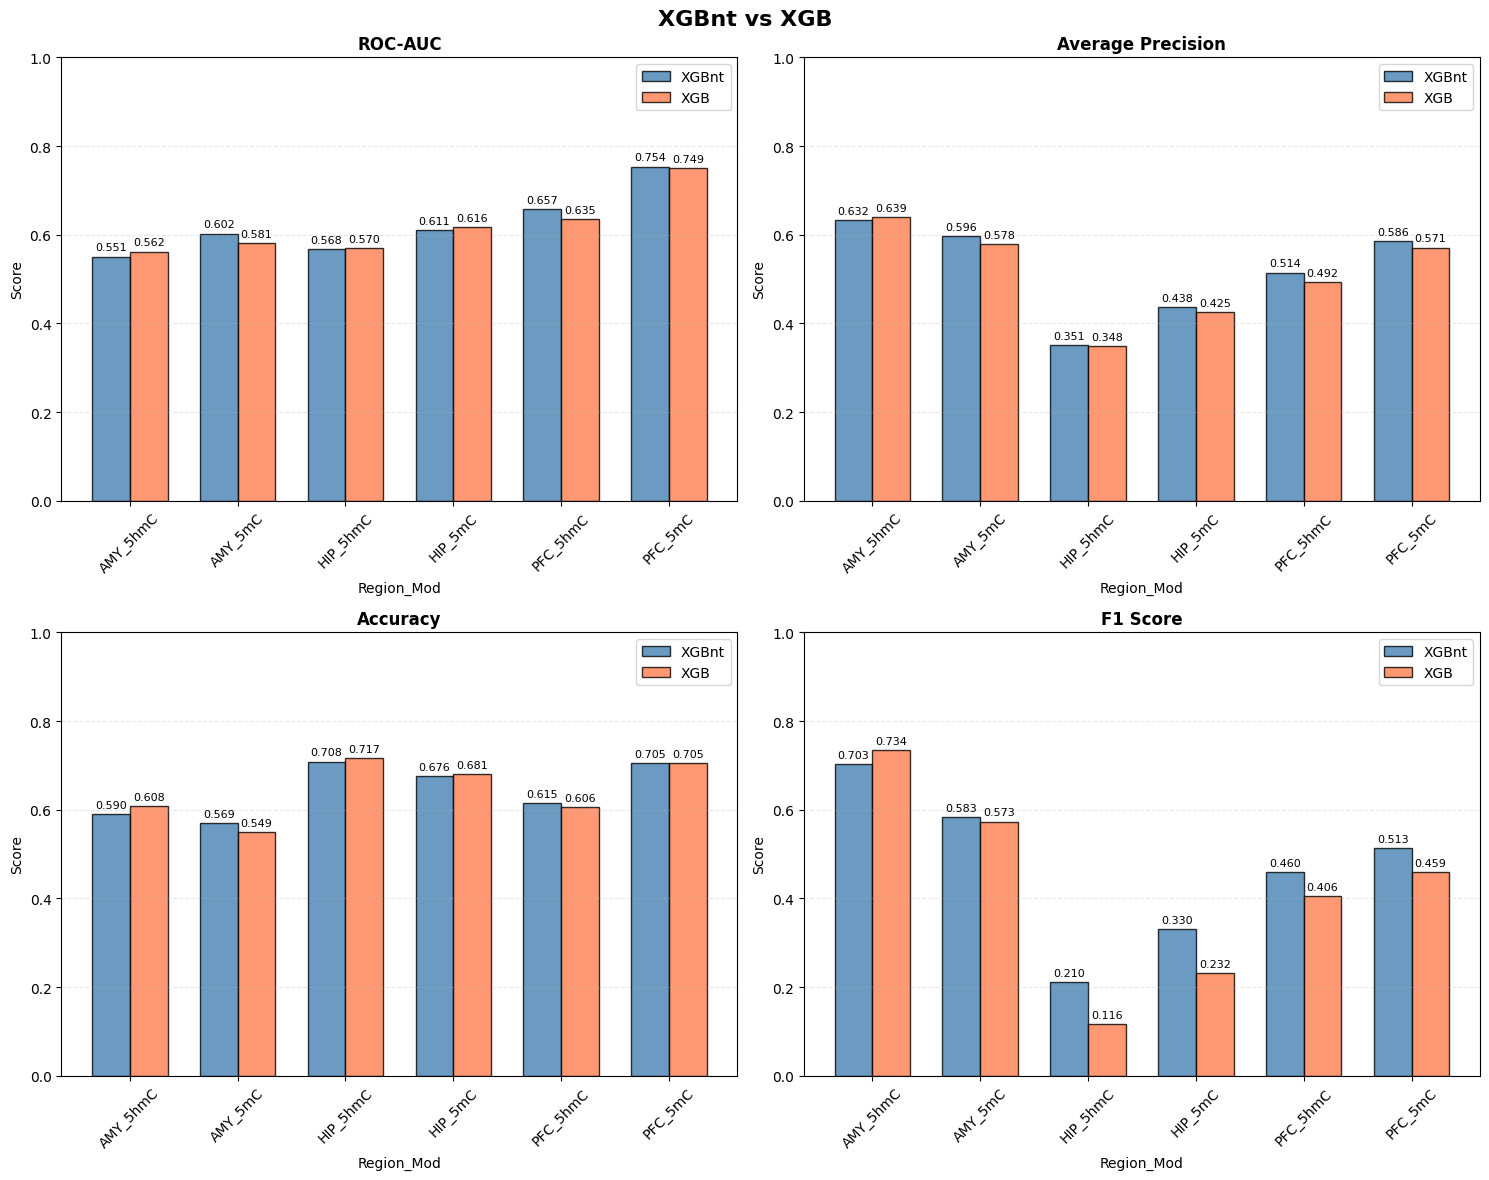

<Figure size 1400x800 with 0 Axes>

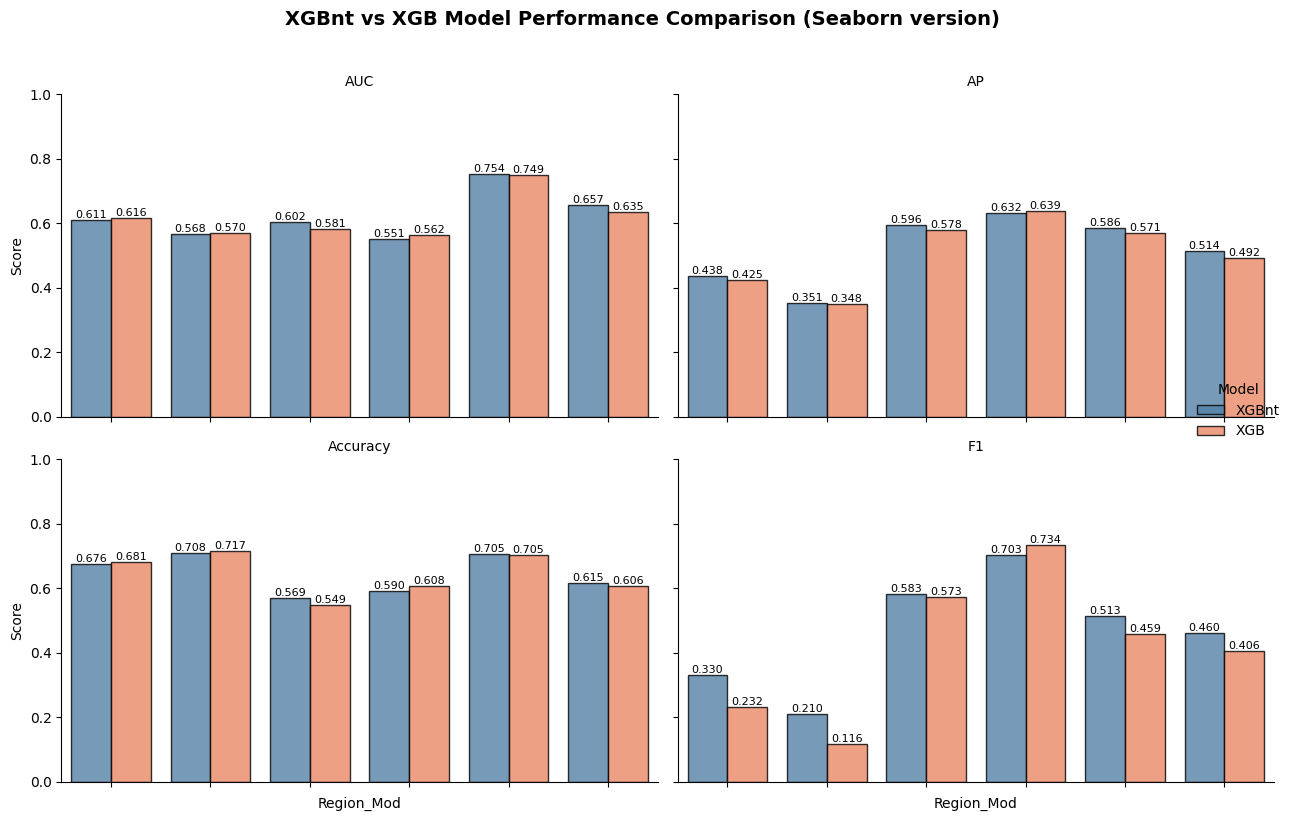

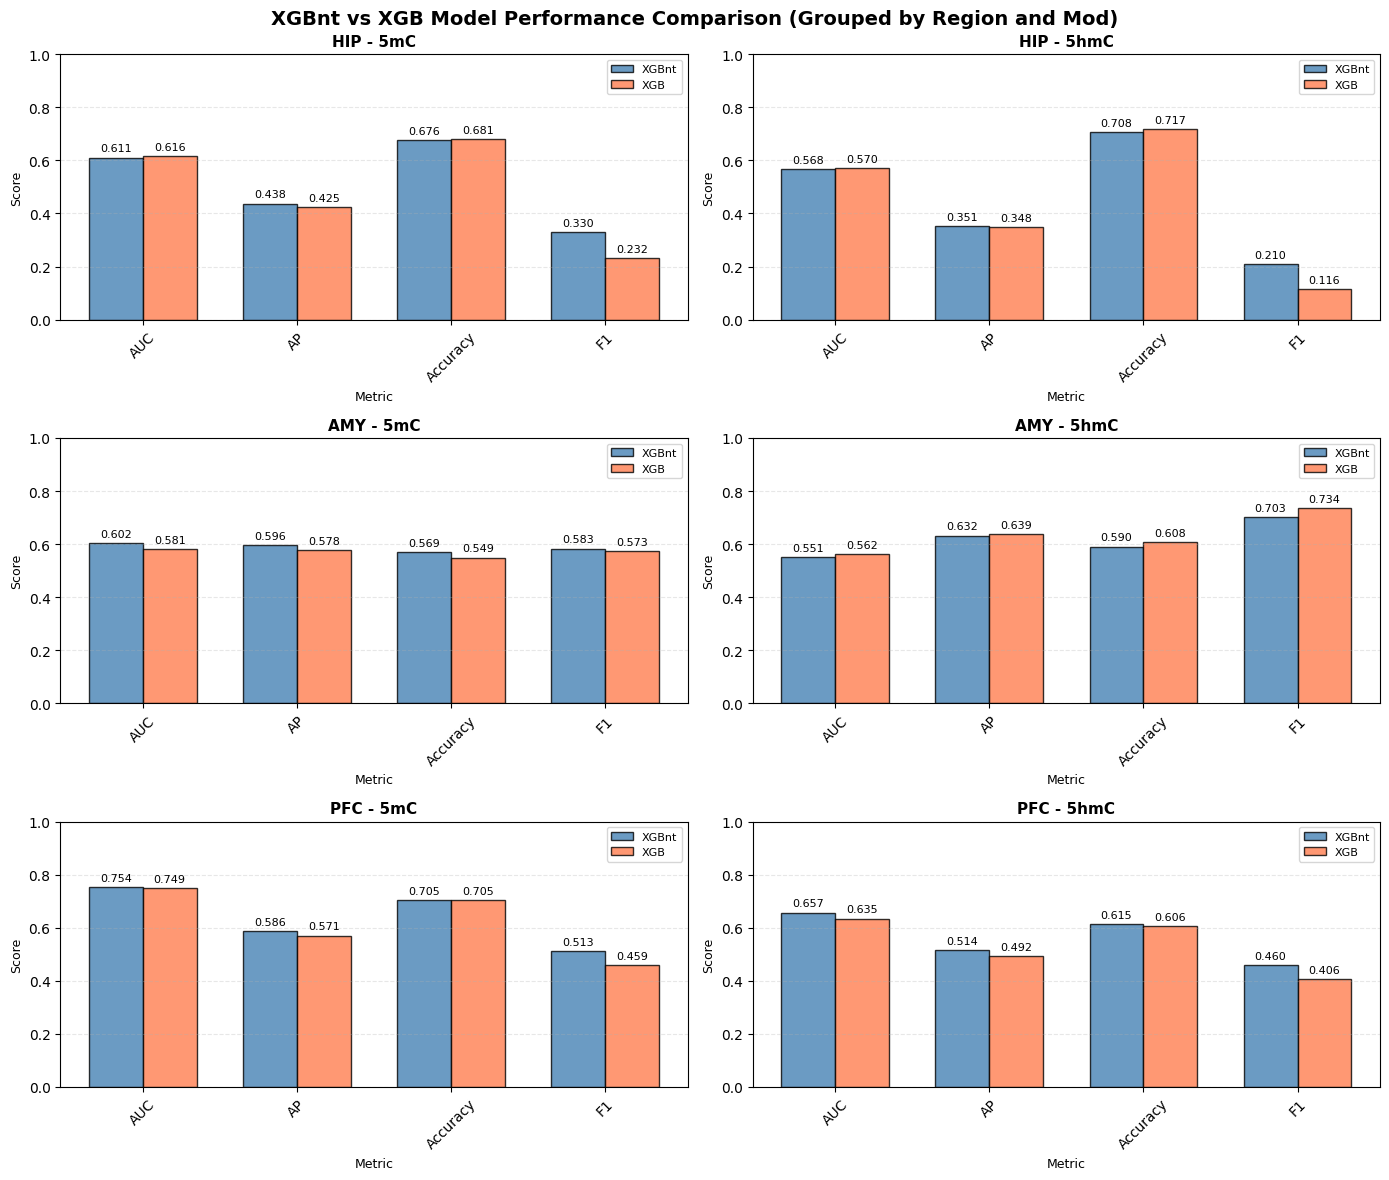


Average Performance Comparison:
   Model       AUC        AP  Accuracy        F1
0    XGB  0.618773  0.508916  0.644137  0.420075
1  XGBnt  0.623785  0.519659  0.644022  0.466743


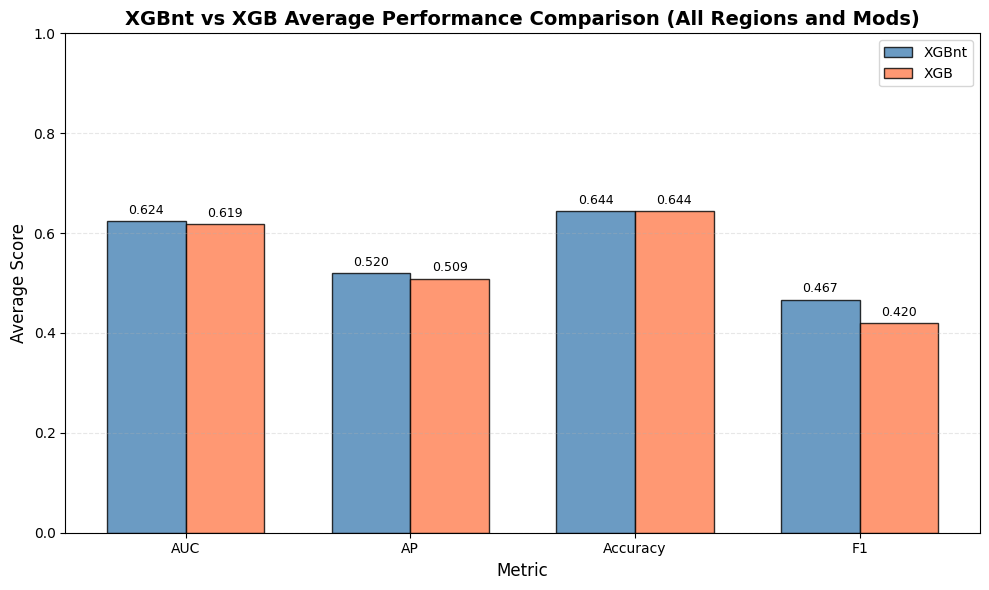

In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
import seaborn as sns

# 设置中文字体和样式
rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# 创建数据框用于存储所有结果
results = []

# 遍历所有region和mod组合
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        key = f'{region}_{mod}'
        if key in pefromdict:
            # 获取XGBnt模型的得分
            xgbnt_scores = {
                'Region_Mod': f'{region}_{mod}',
                'Region': region,
                'Mod': mod,
                'Model': 'XGBnt',
                'AUC': pefromdict[key].get('XGBn_auc', 0),  # 注意这里是XGBn_auc
                'AP': pefromdict[key].get('XGBnt_ap', 0),
                'Accuracy': pefromdict[key].get('XGBnt_accuracy', 0),
                'F1': pefromdict[key].get('XGBnt_f1', 0)
            }
            
            # 获取XGB模型的得分
            xgb_scores = {
                'Region_Mod': f'{region}_{mod}',
                'Region': region,
                'Mod': mod,
                'Model': 'XGB',
                'AUC': pefromdict[key].get('XGB_auc', 0),
                'AP': pefromdict[key].get('XGB_ap', 0),
                'Accuracy': pefromdict[key].get('XGB_accuracy', 0),
                'F1': pefromdict[key].get('XGB_f1', 0)
            }
            
            results.append(xgbnt_scores)
            results.append(xgb_scores)

# 转换为DataFrame
df = pd.DataFrame(results)

# 打印数据检查
print("数据预览:")
print(df.head())
print("\n数据形状:", df.shape)

# 创建分组条形图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('XGBnt vs XGB', fontsize=16, fontweight='bold')

metrics = ['AUC', 'AP', 'Accuracy', 'F1']
titles = ['ROC-AUC', 'Average Precision', 'Accuracy', 'F1 Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # 为每个Region_Mod组合创建分组
    x = np.arange(len(df['Region_Mod'].unique()))  # 6个组合
    width = 0.35  # 柱状图宽度
    
    # 获取XGBnt和XGB的数据
    xgbnt_data = df[df['Model'] == 'XGBnt'].sort_values('Region_Mod')[metric].values
    xgb_data = df[df['Model'] == 'XGB'].sort_values('Region_Mod')[metric].values
    
    # 绘制柱状图
    bars1 = ax.bar(x - width/2, xgbnt_data, width, label='XGBnt', 
                   color='steelblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, xgb_data, width, label='XGB', 
                   color='coral', edgecolor='black', alpha=0.8)
    
    # 添加数值标签
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    
    # 设置图形属性
    ax.set_xlabel('Region_Mod', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sorted(df['Region_Mod'].unique()), rotation=45)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# 备选方案1：使用seaborn的更简洁版本
plt.figure(figsize=(14, 8))

# 将数据转换为长格式
df_melted = pd.melt(df, id_vars=['Region_Mod', 'Model'], 
                    value_vars=metrics,
                    var_name='Metric', value_name='Score')

# 创建分组条形图
g = sns.catplot(data=df_melted, kind='bar',
                x='Region_Mod', y='Score', hue='Model',
                col='Metric', col_wrap=2,
                height=4, aspect=1.5, palette=['steelblue', 'coral'],
                edgecolor='black', alpha=0.8)

g.set_axis_labels("Region_Mod", "Score")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)
g.set(ylim=(0, 1.0))

# 在每个柱子上添加数值
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.suptitle('XGBnt vs XGB Model Performance Comparison (Seaborn version)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 备选方案2：按Region分组的条形图
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for region_idx, region in enumerate(['HIP', 'AMY', 'PFC']):
    for mod_idx, mod in enumerate(['5mC', '5hmC']):
        ax = axes[region_idx, mod_idx]
        
        # 筛选数据
        region_mod_data = df[(df['Region'] == region) & (df['Mod'] == mod)]
        
        if len(region_mod_data) > 0:
            # 准备数据
            xgbnt_row = region_mod_data[region_mod_data['Model'] == 'XGBnt'].iloc[0]
            xgb_row = region_mod_data[region_mod_data['Model'] == 'XGB'].iloc[0]
            
            x = np.arange(len(metrics))
            width = 0.35
            
            bars1 = ax.bar(x - width/2, [xgbnt_row[m] for m in metrics], width,
                          label='XGBnt', color='steelblue', edgecolor='black', alpha=0.8)
            bars2 = ax.bar(x + width/2, [xgb_row[m] for m in metrics], width,
                          label='XGB', color='coral', edgecolor='black', alpha=0.8)
            
            # 添加数值标签
            for bar in bars1:
                height = bar.get_height()
                ax.annotate(f'{height:.3f}',
                          xy=(bar.get_x() + bar.get_width() / 2, height),
                          xytext=(0, 3), textcoords="offset points",
                          ha='center', va='bottom', fontsize=8)
            
            for bar in bars2:
                height = bar.get_height()
                ax.annotate(f'{height:.3f}',
                          xy=(bar.get_x() + bar.get_width() / 2, height),
                          xytext=(0, 3), textcoords="offset points",
                          ha='center', va='bottom', fontsize=8)
            
            ax.set_xlabel('Metric', fontsize=9)
            ax.set_ylabel('Score', fontsize=9)
            ax.set_title(f'{region} - {mod}', fontsize=11, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(metrics, rotation=45)
            ax.legend(fontsize=8)
            ax.grid(True, axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 1.0)

plt.suptitle('XGBnt vs XGB Model Performance Comparison (Grouped by Region and Mod)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 备选方案3：汇总平均性能
# 计算每个模型的平均性能
avg_performance = df.groupby('Model')[metrics].mean().reset_index()
print("\nAverage Performance Comparison:")
print(avg_performance)

# 绘制平均性能条形图
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, avg_performance[avg_performance['Model'] == 'XGBnt'][metrics].values.flatten(), 
               width, label='XGBnt', color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, avg_performance[avg_performance['Model'] == 'XGB'][metrics].values.flatten(), 
               width, label='XGB', color='coral', edgecolor='black', alpha=0.8)

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('XGBnt vs XGB Average Performance Comparison (All Regions and Mods)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

In [121]:
# draw a barplot comparing the AUC of the two models (with and without nt pc) for each region and mod type
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [122]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedMethModel_CNN(nn.Module):
    def __init__(self, nt_dim=256, num_cell_types=9):
        super().__init__()

        # ---------- CNN over sequence ----------
        # 输入: (B, Dim=256, L)
        cnn_channels = 128
        kernel_sizes = [5, 9, 13]   # motif-like receptive fields

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=nt_dim,
                out_channels=cnn_channels,
                kernel_size=k,
                padding=k // 2
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(0.3)

        # CNN 输出维度 = cnn_channels * len(kernel_sizes)
        cnn_out_dim = cnn_channels * len(kernel_sizes)

        # ---------- MLP: sequence → cell-type methylation propensity ----------
        self.mlp = nn.Sequential(
            nn.Linear(cnn_out_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_cell_types),
            nn.Sigmoid()   # 每个细胞类型的“固有甲基化率”
        )

    def forward(self, nt_embeddings, atac_signals):
        """
        nt_embeddings: (B, L, Dim)
        atac_signals:  (B, N=celltypes), 已归一化
        """

        # ---- CNN 扫描整片区域 ----
        # 转成 Conv1d 格式: (B, Dim, L)
        x = nt_embeddings.permute(0, 2, 1)

        conv_feats = []
        for conv in self.convs:
            h = F.relu(conv(x))              # (B, C, L)
            p = F.max_pool1d(h, kernel_size=h.shape[-1]).squeeze(-1)  # (B, C)
            conv_feats.append(p)

        # 拼接不同 kernel 的特征
        seq_feat = torch.cat(conv_feats, dim=1)  # (B, C * K)
        seq_feat = self.dropout(seq_feat)

        # ---- 预测细胞类型特异的甲基化率 ----
        predicted_cell_meth = self.mlp(seq_feat)  # (B, N)

        # ---- 物理反卷积 ----
        out = torch.sum(predicted_cell_meth * atac_signals, dim=1)  # (B,)

        return out, predicted_cell_meth


In [123]:
cnn_model = ImprovedMethModel_CNN(nt_dim=256, num_cell_types=8)

In [129]:
nt_emb = pefromdict["HIP_5mC"]["final_emb"]     # (n, L, 256)
atac   = pefromdict["HIP_5mC"]["X"]  # (n, N)
y      = pefromdict["HIP_5mC"]["y_reg"]  # (n,)


In [125]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score
)


# -----------------------------
# 1. Dataset
# -----------------------------
class MethDataset(Dataset):
    def __init__(self, nt_emb, atac, y):
        self.nt_emb = torch.tensor(nt_emb, dtype=torch.float32)
        self.atac   = torch.tensor(atac, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.float32)  # BCE expects float {0,1}

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.nt_emb[idx], self.atac[idx], self.y[idx]


# -----------------------------
# 2. Train / Eval Functions
# -----------------------------
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0

    for nt_emb, atac, y in loader:
        nt_emb, atac, y = nt_emb.to(device), atac.to(device), y.to(device)

        logits, _ = model(nt_emb, atac)   # logits shape (B,)
        loss = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    probs, trues = [], []

    for nt_emb, atac, y in loader:
        nt_emb, atac = nt_emb.to(device), atac.to(device)

        logits, _ = model(nt_emb, atac)

        prob = torch.sigmoid(logits)   # convert logits → probability

        probs.append(prob.cpu().numpy())
        trues.append(y.numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)

    pred = (probs >= 0.5).astype(int)

    auc = roc_auc_score(trues, probs)
    ap  = average_precision_score(trues, probs)
    acc = accuracy_score(trues, pred)
    f1  = f1_score(trues, pred)

    return auc, ap, acc, f1


# -----------------------------
# 3. Main Training Script
# -----------------------------
def run_training_BCE(nt_emb, atac, y, model,
                     lr=1e-3, batch_size=64, max_epochs=50):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    # train/val split
    X_train, X_val, A_train, A_val, y_train, y_val = train_test_split(
        nt_emb, atac, y, test_size=0.2, random_state=42, stratify=y
    )

    train_ds = MethDataset(X_train, A_train, y_train)
    val_ds   = MethDataset(X_val,   A_val,   y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # ---- class imbalance handling ----
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # early stopping
    best_auc = -1e9
    patience = 100
    patience_counter = 0

    print("\nStart BCE classification training...\n")

    for epoch in range(max_epochs):

        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        auc, ap, acc, f1 = evaluate(model, val_loader, device)

        print(f"Epoch {epoch:02d} | Loss={train_loss:.4f} "
              f"| AUC={auc:.3f} | AP={ap:.3f} | Acc={acc:.3f} | F1={f1:.3f}")

        # early stopping based on AUC
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model_BCE.pt")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("\nEarly stopping triggered.")
            break

    print("\nBest Val AUC =", best_auc)
    print("Saved model: best_model_BCE.pt")

    return model


In [126]:
cnn_model = ImprovedMethModel_CNN(nt_dim=256, num_cell_types=8)

trained_model = run_training_BCE(
    nt_emb=nt_emb,
    atac=atac,
    y=y,
    model=cnn_model,
    batch_size=16,
    max_epochs=200,
)


/tmp/ipykernel_968165/2716535760.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.nt_emb = torch.tensor(nt_emb, dtype=torch.float32)



Start BCE classification training...

Epoch 00 | Loss=1.0043 | AUC=0.413 | AP=0.292 | Acc=0.368 | F1=0.339
Epoch 01 | Loss=0.9456 | AUC=0.412 | AP=0.287 | Acc=0.363 | F1=0.337
Epoch 02 | Loss=0.9437 | AUC=0.434 | AP=0.302 | Acc=0.391 | F1=0.351
Epoch 03 | Loss=0.9411 | AUC=0.420 | AP=0.297 | Acc=0.384 | F1=0.348
Epoch 04 | Loss=0.9396 | AUC=0.415 | AP=0.291 | Acc=0.375 | F1=0.342
Epoch 05 | Loss=0.9414 | AUC=0.416 | AP=0.294 | Acc=0.370 | F1=0.337
Epoch 06 | Loss=0.9439 | AUC=0.406 | AP=0.285 | Acc=0.360 | F1=0.330
Epoch 07 | Loss=0.9418 | AUC=0.407 | AP=0.290 | Acc=0.365 | F1=0.335
Epoch 08 | Loss=0.9393 | AUC=0.406 | AP=0.291 | Acc=0.358 | F1=0.336
Epoch 09 | Loss=0.9415 | AUC=0.418 | AP=0.291 | Acc=0.368 | F1=0.332
Epoch 10 | Loss=0.9406 | AUC=0.409 | AP=0.294 | Acc=0.368 | F1=0.336
Epoch 11 | Loss=0.9398 | AUC=0.412 | AP=0.286 | Acc=0.368 | F1=0.336
Epoch 12 | Loss=0.9407 | AUC=0.421 | AP=0.297 | Acc=0.379 | F1=0.343
Epoch 13 | Loss=0.9411 | AUC=0.417 | AP=0.300 | Acc=0.379 | F1=0

In [ ]:


reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    n_components=2,
    metric="cosine",
    random_state=42
)

for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        X_pca = pefromdict[f'{region}_{mod}']['seq_pca']

        X_umap = reducer.fit_transform(X_pca)
        print(X_umap.shape)
        # plt.figure(figsize=(6, 6))
        # plt.scatter(
        #     X_umap[:, 0],
        #     X_umap[:, 1],
        #     s=10,
        #     alpha=0.6
        # )
        # plt.xlabel("UMAP-1")
        # plt.ylabel("UMAP-2")
        # plt.title("NT region embeddings (UMAP)")
        # plt.show()

        plt.figure(figsize=(6, 6))
        sns.scatterplot(
            x=X_umap[:, 0],
            y=X_umap[:, 1],
            hue=pefromdict[f'{region}_{mod}']['seq_pca'][:, 0],      # e.g. list or array
            s=8,
            alpha=0.7
        )
        plt.title("NT embeddings colored by label")
        plt.show()



In [ ]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
        #cv = KFold(n_splits=10, shuffle=True, random_state=42)
        #gss = GroupShuffleSplit(n_splits=10, test_size=0.1, random_state=42)

        # XGBoost regressor
        model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=8,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        X = pefromdict[f'{region}_{mod}']['X']
        # concatenate with first pc in sequence pca
        #X = np.concatenate([X, pefromdict[f'{region}_{mod}']['seq_pca']], axis=1)
        X = np.concatenate([X, pefromdict[f'{region}_{mod}']['seq_pca'][:,:2]], axis=1)
        #X = pefromdict[f'{region}_{mod}']['X']*pefromdict[f'{region}_{mod}']['seq_pca'][:, :1]

        # MUST be continuous (e.g., diff.Methy)
        y = pefromdict[f'{region}_{mod}']['y'].astype(np.float32)


        # out-of-fold predictions (no leakage)
        #y_pred_oof = cross_val_predict(model, X, y, cv=cv, method="predict")
        y_pred_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        #y_pred_oof = cross_val_predict(model, X, y, cv=gss, groups=chr, method="predict")

        r2 = r2_score(y, y_pred_oof)
        rmse = root_mean_squared_error(y, y_pred_oof)
        mae = mean_absolute_error(y, y_pred_oof)

        if np.std(y) > 1e-12 and np.std(y_pred_oof) > 1e-12:
            r, p = pearsonr(y, y_pred_oof)
        else:
            r, p = np.nan, np.nan

        print(region, mod)
        print("R2:", r2)
        print("Pearson r:", r, "p:", p)
        print("RMSE:", rmse)
        print("MAE:", mae)
        print("-" * 60)

        # fit final model on all data
        model.fit(X, y)

        # in-sample predictions
        y_pred = model.predict(X)

        # update dict (keep existing df/feature_cols if already stored)
        pefromdict[f'{region}_{mod}'].update({
            'model_reg': model,
            'y_pred_oof_reg': y_pred_oof,
            'y_pred_reg': y_pred
        })


In [ ]:
y

In [ ]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:

        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5)
        X = pefromdict[f'{region}_{mod}']['X']
        X = np.concatenate([X, pefromdict[f'{region}_{mod}']['seq_pca'][:,:2]], axis=1)

        y = pefromdict[f'{region}_{mod}']['y'].astype(int)

        # XGBoost classifier (binary logistic)
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        #y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        y_prob_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print(region, mod)
        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))
        print("-" * 60)

        # fit final model on all data
        # model.fit(X, y)

        # # in-sample probs/preds (for downstream SHAP etc.)
        # y_prob = model.predict_proba(X)[:, 1]
        # y_pred = (y_prob >= 0.5).astype(int)

        # pefromdict[f'{region}_{mod}'] = {
        #     'model': model,
        #     'X': X,
        #     'y': y,
        #     'y_prob_oof': y_prob_oof,
        #     'y_pred_oof': y_pred_oof,
        #     'y_prob': y_prob,
        #     'y_pred': y_pred,
        #     'feature_cols': feature_cols,
        #     'df': df_merged_region
        # }
